# Analyse du model et interpretation des resultats

In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder\
    .master("local[*]")\
    .appName("Accident")\
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")

your 131072x1 screen size is bogus. expect trouble
25/06/19 12:18:33 WARN Utils: Your hostname, DESKTOP-NHT3FJU resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
25/06/19 12:18:33 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
25/06/19 12:18:33 WARN Utils: Your hostname, DESKTOP-NHT3FJU resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
25/06/19 12:18:33 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/06/19 12:18:34 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/06/19 12:18:34 WARN NativeCodeLoader: Unable to load native-hadoo

In [2]:
from pyspark.ml.pipeline import PipelineModel

best_model = PipelineModel.load("final_accident_model")

test = spark.read.parquet("test_data.parquet")
train = spark.read.parquet("train_data.parquet")

In [4]:
columns_to_keep = [
    "Severity",

    'Start_Lat', 'Start_Lng', 'Distance(mi)',

    'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)',
    'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)',

    'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit',
    'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming',
    'Traffic_Signal', 'Turning_Loop',

    'Sunrise_Sunset', 'Civil_Twilight',
    'Nautical_Twilight', 'Astronomical_Twilight',

    'Weather_Condition', 'Wind_Direction',
    'State'
]

feature_cols = columns_to_keep[1:]
feature_cols.remove("Wind_Chill(F)")
feature_cols.remove("State")

columns_to_encode = [
    "Sunrise_Sunset", "Civil_Twilight", "Nautical_Twilight", "Astronomical_Twilight",
    "Weather_Condition", "Wind_Direction", "Region"
]

numerical_features = [col for col in feature_cols if col not in columns_to_encode]

In [5]:
n = len(columns_to_encode)
indexers = best_model.stages[:n]
encoders = best_model.stages[n:2*n]
assembler = best_model.stages[-3]
scaler = best_model.stages[-2]
lr_model = best_model.stages[-1]

In [6]:
encoded_feature_names = []

for encoder in encoders:
    input_col = encoder.getInputCol().replace("_idx", "")
    num_categories = encoder.categorySizes[0]
    
    # Si dropLast=True, on ne crée que n-1 colonnes
    for i in range(num_categories - 1):
        encoded_feature_names.append(f"{input_col}_{i}")

full_feature_names = encoded_feature_names + numerical_features


In [7]:
import pandas as pd

coef_matrix = lr_model.coefficientMatrix.toArray()  # shape: (n_classes, n_features)

# Créer un DataFrame avec une ligne par feature et une colonne par classe
columns = [f"Classe_{i}" for i in range(coef_matrix.shape[0])]
coef_df = pd.DataFrame(coef_matrix.T, index=full_feature_names, columns=columns)

# Moyenne des poids absolus (influence globale)
coef_df["mean_abs_weight"] = coef_df.abs().mean(axis=1)


In [8]:
top_k = 15
top_features = coef_df.sort_values("mean_abs_weight", ascending=False).head(top_k)

print("Top features les plus influentes :")
display(top_features)

Top features les plus influentes :


,Classe_0,Classe_1,Classe_2,Classe_3,mean_abs_weight
Traffic_Signal,0.052685,-0.242582,-0.062337,0.252234,0.152460
Crossing,0.083311,-0.202808,-0.046407,0.165903,0.124607
Distance(mi),0.040244,-0.091302,0.182446,-0.131388,0.111345
Temperature(F),-0.134453,-0.019202,-0.046367,0.200022,0.100011
Weather_Condition_3,-0.053757,0.120558,0.073574,-0.140374,0.097066
Weather_Condition_0,0.051813,-0.171825,-0.022240,0.142251,0.097032
Start_Lat,-0.143269,0.008274,0.160913,-0.025917,0.084593
Stop,0.066890,-0.166235,0.046727,0.052618,0.083117
Start_Lng,-0.014797,-0.125812,0.163636,-0.023026,0.081818
Pressure(in),0.052436,0.109213,-0.058828,-0.102821,0.080825


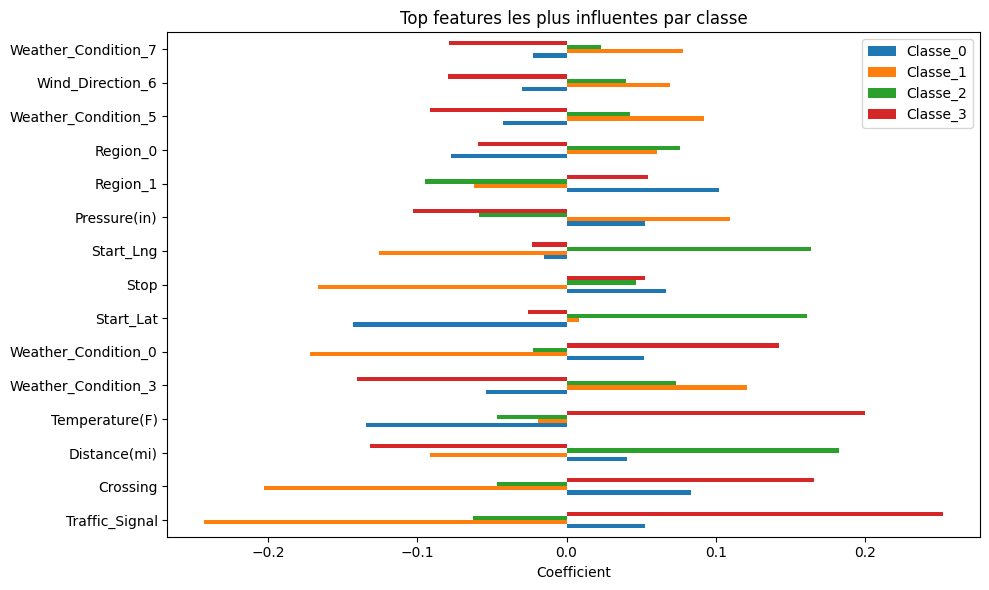

In [9]:
import matplotlib.pyplot as plt

top_features[columns].plot(kind="barh", figsize=(10, 6))
plt.title("Top features les plus influentes par classe")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()

In [10]:
from pyspark.ml.feature import StringIndexerModel

encoder_model = best_model.stages[0]
labels = encoder_model.labels

indexer_labels = {}
for stage in best_model.stages:
    if isinstance(stage, StringIndexerModel):
        original_col = stage.getInputCol()
        indexer_labels[original_col] = stage.labels


def decode_feature_name(feature_name):
    for base_col in indexer_labels:
        if feature_name.startswith(base_col):
            try:
                index = int(feature_name.split("_")[-1])
                return f"{base_col}={indexer_labels[base_col][index]}"
            except:
                pass
    return feature_name  # si c’est une feature numérique


readable_index = [decode_feature_name(f) for f in coef_df.index]
coef_df.index = readable_index


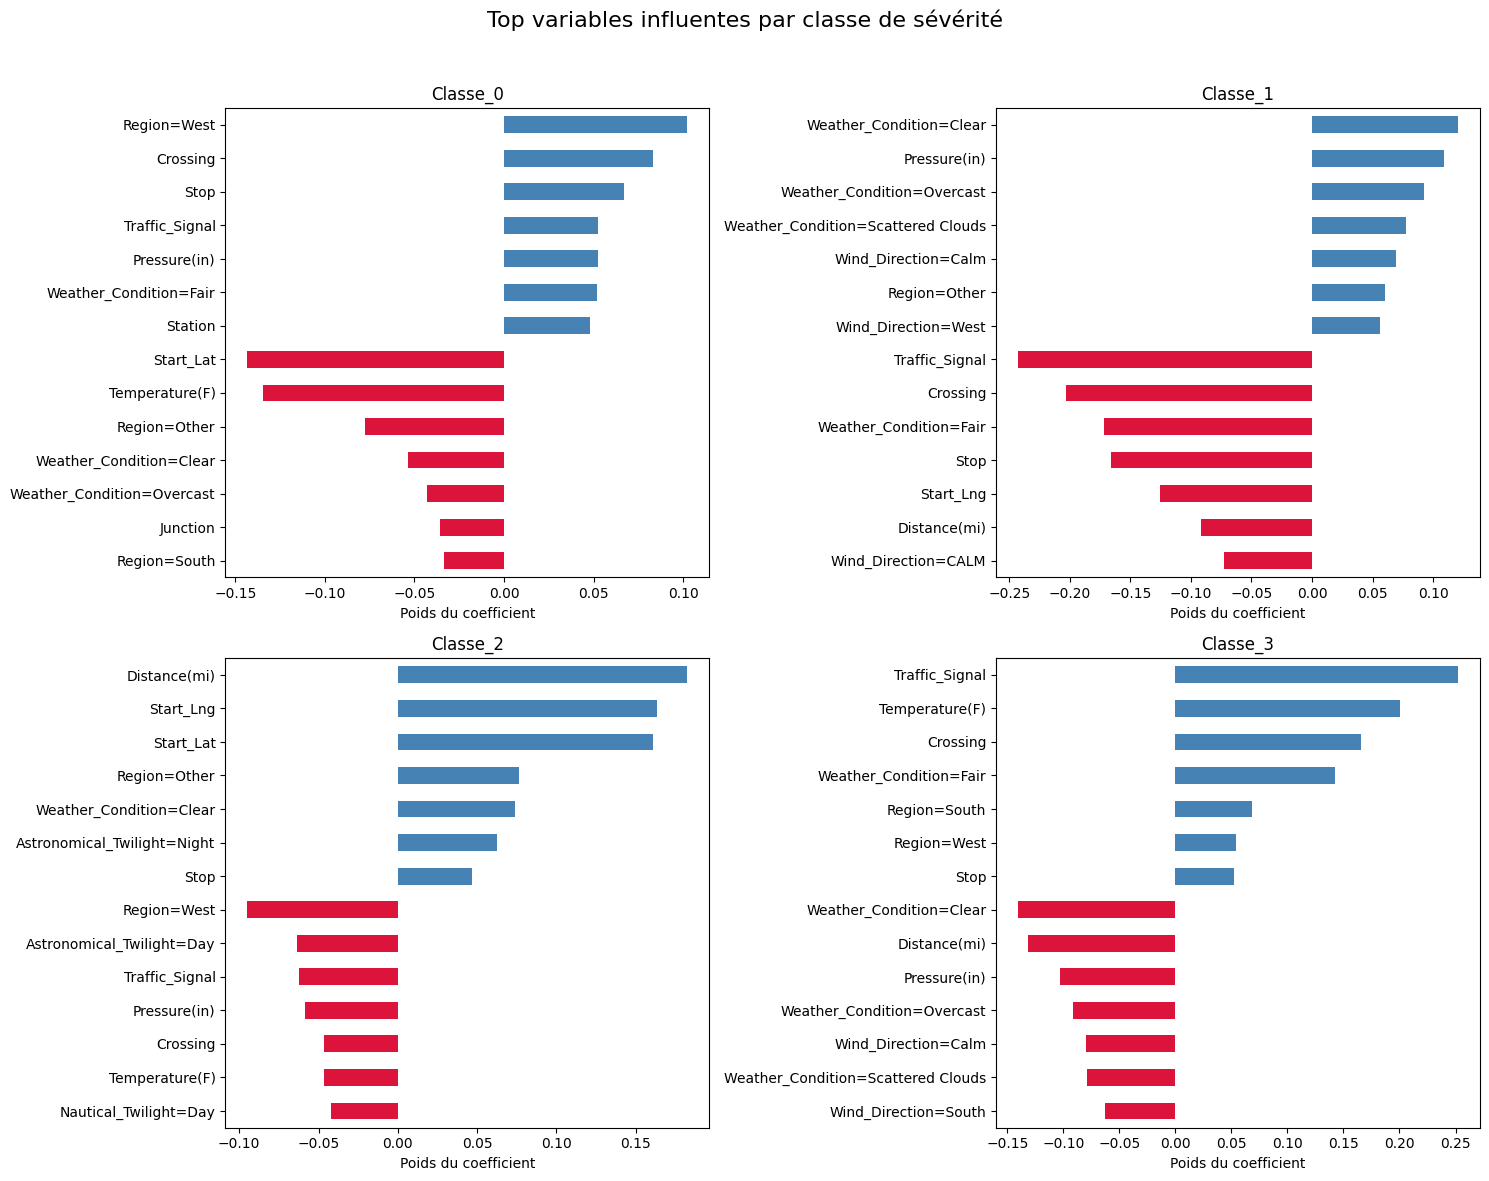

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

# Paramètres
n_top = 7  # top features positives/négatives par classe
n_cols = 2
n_rows = (len(columns) + 1) // n_cols

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(columns[:4]):  # Affiche les 4 classes (Classe_0 à Classe_3)
    ax = axes[i]

    top_pos = coef_df[col].sort_values(ascending=False).head(n_top)
    top_neg = coef_df[col].sort_values().head(n_top)
    top_features = pd.concat([top_pos, top_neg])
    colors = ["crimson" if v < 0 else "steelblue" for v in top_features]

    top_features.plot(kind="barh", ax=ax, color=colors)
    ax.set_title(f"{col}", fontsize=12)
    ax.set_xlabel("Poids du coefficient")
    ax.invert_yaxis()

# Supprimer les axes inutilisés s’il y en a
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Top variables influentes par classe de sévérité", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [15]:
spark.stop()